# COT_lab — Results

Loads `outputs/eval_results/` and renders the final accuracy table, ReCEval summary, and per-condition violin/bar plots. Run after Stage 5 has produced its CSVs.

In [1]:
from pathlib import Path
import json
import math

import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path('..').resolve()
EVAL = REPO_ROOT / 'outputs' / 'eval_results'
PLOTS = REPO_ROOT / 'outputs' / 'plots'
print('eval dir:', EVAL)

eval dir: /workspaces/COT_lab/outputs/eval_results


## 1. Accuracy

Reference (Ho et al. 2023, FLAN-T5-base on GSM8K): baseline 2.50%, standard FT 5.08%, CoT FT 4.40%.

In [2]:
acc = pd.read_csv(EVAL / 'accuracy.csv')
acc['accuracy_pct'] = (acc['accuracy'] * 100).round(2)
acc

,condition,n,correct,accuracy,accuracy_pct
0,baseline,1319,57,0.043215,4.32
1,student_direct_ft,1319,69,0.052312,5.23
2,student_set_a,1319,35,0.026535,2.65
3,student_set_b,1319,44,0.033359,3.34
4,student_set_c,1319,38,0.028810,2.88


/tmp/ipykernel_18154/2546823937.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(acc['condition'], rotation=25, ha='right')


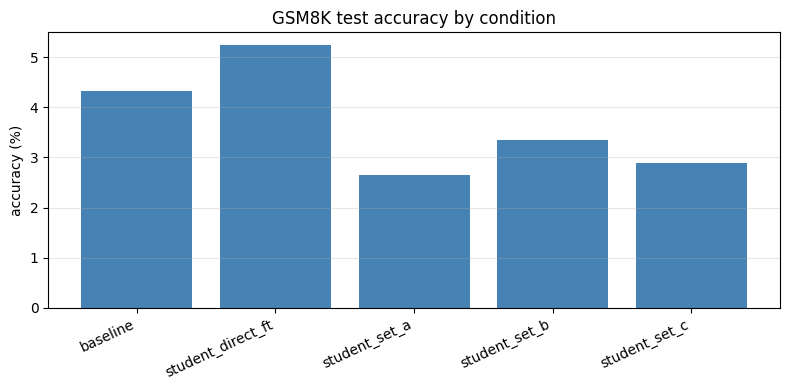

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(acc['condition'], acc['accuracy_pct'], color='steelblue')
ax.set_xticklabels(acc['condition'], rotation=25, ha='right')
ax.set_ylabel('accuracy (%)')
ax.set_title('GSM8K test accuracy by condition')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

## 2. ReCEval summary

In [4]:
rec = pd.read_csv(EVAL / 'receval_summary.csv')
rec

,condition,n,intra_mean,intra_std,intra_min,intra_max,inter_mean,inter_std,inter_min,inter_max,info_mean,info_std,info_min,info_max
0,baseline,1319,0.968506,0.028254,0.314369,0.997232,0.057038,0.196787,0.000069,0.997865,-1.327780,1.041135,-9.915250,3.155196
1,student_direct_ft,1319,0.912140,0.021117,0.852081,0.967920,0.722436,0.360894,0.001202,0.999702,1.479269,1.354503,-2.776712,7.684443
2,student_set_a,1319,0.919987,0.031354,0.619238,0.991551,0.068232,0.192341,0.000054,0.995366,-2.520732,1.701810,-11.504503,0.244607
3,student_set_b,1319,0.912224,0.033616,0.029409,0.992651,0.062473,0.184683,0.000054,0.990783,-2.423505,1.676565,-11.504503,0.396955
4,student_set_c,1319,0.912835,0.022847,0.852081,0.989544,0.061963,0.180330,0.000054,0.984016,-2.384814,1.685116,-11.504503,0.276217


In [5]:
# Per-example distributions
by_cond = {}
for p in sorted(EVAL.glob('*_receval.jsonl')):
    cond = p.stem.replace('_receval', '')
    with p.open() as f:
        by_cond[cond] = [json.loads(l) for l in f if l.strip()]
list(by_cond.keys())

['baseline',
 'student_direct_ft',
 'student_set_a',
 'student_set_b',
 'student_set_c']

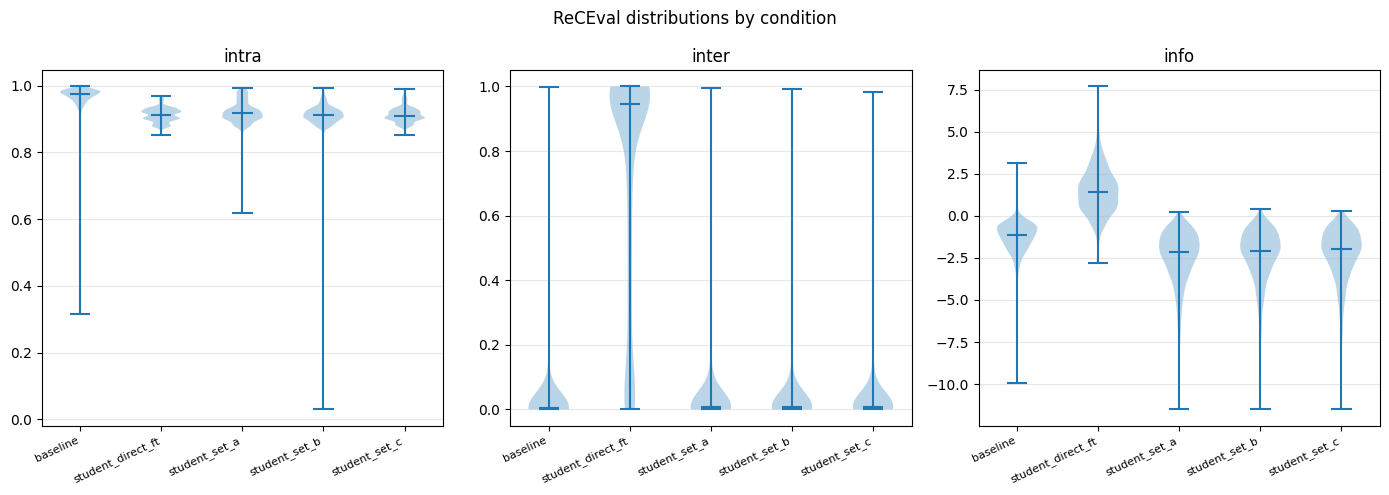

In [6]:
metrics = ['intra', 'inter', 'info']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, metrics):
    data = [[r[metric] for r in by_cond[c] if not math.isnan(r.get(metric, float('nan')))] for c in by_cond]
    labels = list(by_cond.keys())
    ax.violinplot(data, showmedians=True)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
    ax.set_title(metric)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('ReCEval distributions by condition')
fig.tight_layout()
plt.show()

## 3. Accuracy x ReCEval — "right answer, wrong reasoning?"

For each condition, split per-example ReCEval scores by whether the predicted answer is correct.

In [7]:
def is_correct(row):
    p, g = row.get('parsed_answer'), row.get('gold_answer')
    if p is None or g is None:
        return False
    try:
        return abs(float(p) - float(g)) < 1e-6
    except (TypeError, ValueError):
        return False

rows = []
for cond, recs in by_cond.items():
    for r in recs:
        rows.append({
            'condition': cond,
            'correct': is_correct(r),
            'intra': r.get('intra'),
            'inter': r.get('inter'),
            'info': r.get('info'),
        })
df = pd.DataFrame(rows)
df.groupby(['condition', 'correct'])[metrics].mean().round(3)

intra  inter   info
condition         correct                     
baseline          False    0.968  0.055 -1.331
                  True     0.971  0.108 -1.251
student_direct_ft False    0.912  0.728  1.478
                  True     0.914  0.613  1.499
student_set_a     False    0.920  0.070 -2.514
                  True     0.926  0.021 -2.759
student_set_b     False    0.912  0.064 -2.427
                  True     0.916  0.021 -2.310
student_set_c     False    0.913  0.063 -2.375
                  True     0.915  0.031 -2.718